In [40]:
import xarray as xr

#### Create a presence dataset

In [41]:
fishing = xr.open_zarr("./data/processed/GFW_AIS.zarr", consolidated=True)
esp_trawl = fishing.where(
    (fishing["flag"] == "ESP") & (fishing["geartype"] == "TRAWLERS"),
    drop=True
)
esp_trawl = esp_trawl.reset_index(["flag", "geartype"], drop=True)

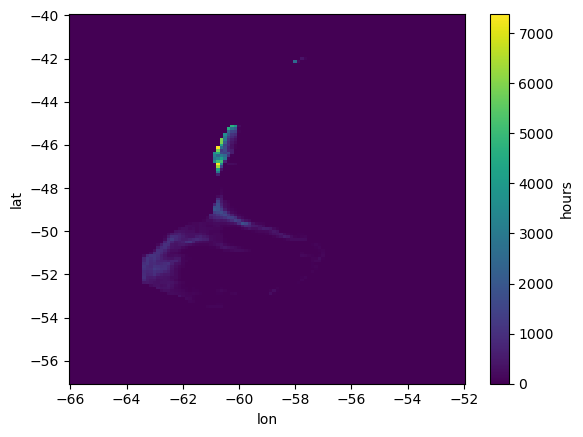

In [42]:
esp_trawl["hours"].sum(dim=["time"]).plot()

In [43]:
presence_esp_trawl = (esp_trawl > 6).astype(int)
esp_trawl["presence"]= presence_esp_trawl["hours"]
esp_trawl = esp_trawl.squeeze(dim=["flag", "geartype"])
esp_trawl.to_netcdf("./data/processed/dynamic/GFW_ESP_TRAWL.nc", mode="w")

In [44]:
esp_trawl

<xarray.Dataset> Size: 31MB
Dimensions:   (time: 168, lat: 137, lon: 113)
Coordinates:
  * lat       (lat) float64 1kB -57.0 -56.88 -56.75 ... -40.25 -40.12 -40.0
  * lon       (lon) float64 904B -66.0 -65.88 -65.75 ... -52.25 -52.12 -52.0
  * time      (time) datetime64[ns] 1kB 2012-01-01 2012-02-01 ... 2025-12-01
Data variables:
    hours     (time, lat, lon) float64 21MB dask.array<chunksize=(42, 35, 57), meta=np.ndarray>
    presence  (time, lat, lon) int32 10MB dask.array<chunksize=(42, 35, 57), meta=np.ndarray>
Attributes:
    created_by:     Ruben Barriuso
    description:    Monthly fishing hours per grid cell in the SW Atlantic, \...
    regrid_method:  conservative
    resolution:     0.125x0.125 degree
    source:         Global Fishing Watch (GFW)
    title:          Regrided SW Atlantic GFW AIS Fishing Effort Data (2012-2024)

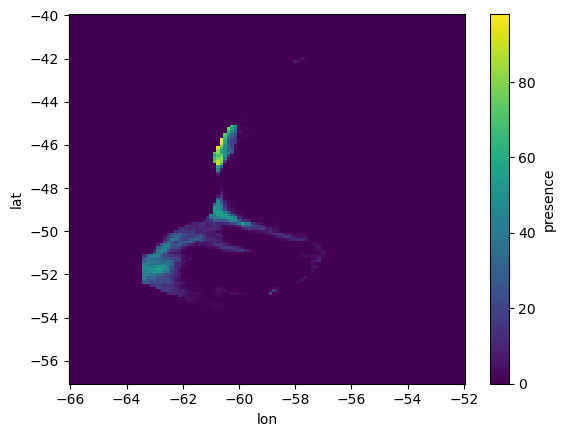

In [45]:
esp_trawl["presence"].sum(dim=["time"]).plot()